# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [2]:
# Import the library

from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

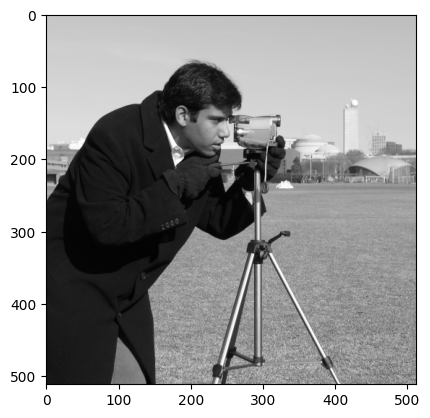

In [3]:
# ── Load image ────────────────────────────────────

from skimage import data

img_array = data.camera()
img = Image.fromarray(img_array)

plt.imshow(img, cmap='gray')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [4]:
# Get the size of the image

# scaling factors
width, height = img.size

cx = 2
cy = 2

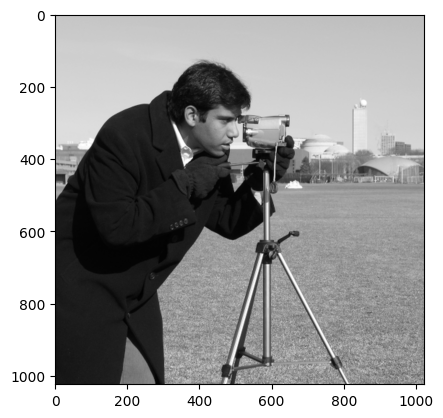

In [5]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method

new_width = int(width * cx)
new_height = int(height * cy)

scaled_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

plt.imshow(scaled_img, cmap='gray')
plt.show()

In [6]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [7]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

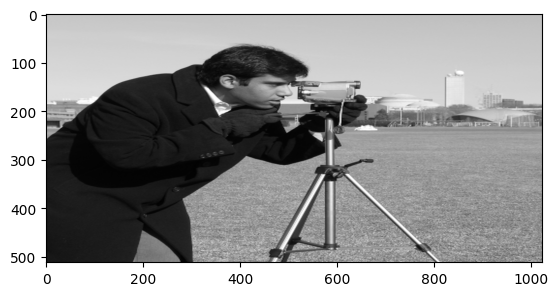

In [8]:
non_uniform_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

plt.imshow(non_uniform_img, cmap='gray')
plt.show()

In [9]:
non_uniform_img.save("task1_1_nonuniform_scaled.jpg")

print("Original size:", img.size)
print("New size:", non_uniform_img.size)

Original size: (512, 512)
New size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


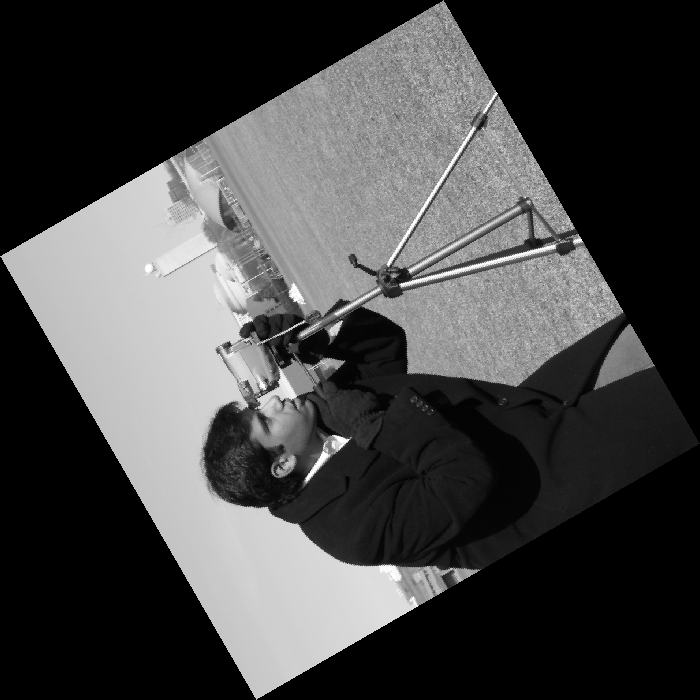

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img = img.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

rotated_img

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────

w, h = img.size

In [12]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5

shx = shear_factor
shy = 0

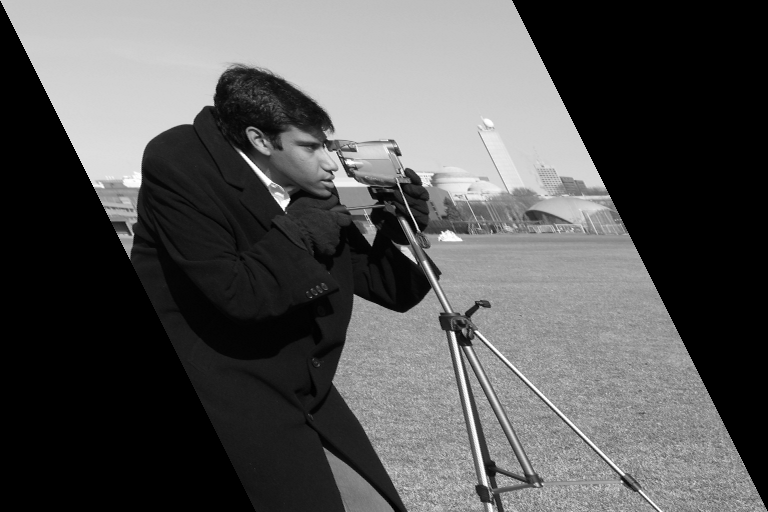

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

new_width = w + int(abs(shx) * h)

sheared_img = img.transform(
    (new_width, h),
    Image.AFFINE,
    (1, -shx, 0, shy, 1, 0),
    resample=Image.BICUBIC
)

sheared_img

In [14]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

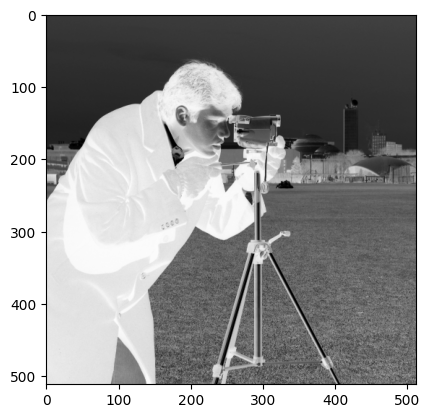

In [19]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

arr = np.array(img)

negative_arr = 255 - arr

negative_img = Image.fromarray(negative_arr)

negative_img.save("task2_1_negative.jpg")

plt.imshow(negative_img, cmap='gray')
plt.show()


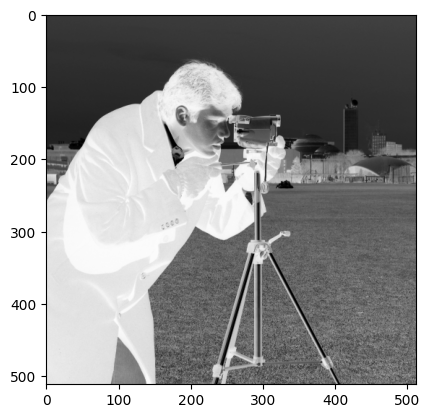

In [20]:
# Method 2: PIL's ImageOps

negative_img2 = ImageOps.invert(img)

negative_img2.save("task2_1_negative_pil.jpg")

plt.imshow(negative_img2, cmap='gray')
plt.show()

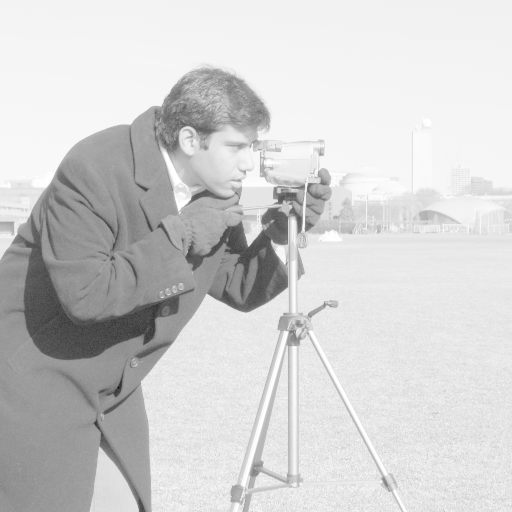

In [21]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

arr = np.array(img).astype(float)

c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = Image.fromarray(
    np.uint8(log_transformed_arr)
)

log_transformed_arr

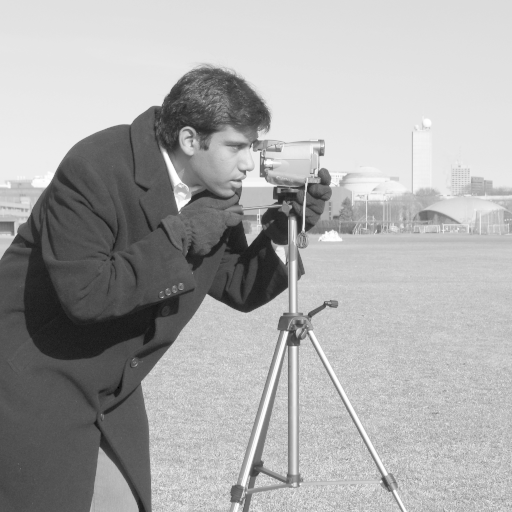

In [22]:

# ── 3. Power-law / Gamma correction ───────────────

gamma = 0.5

arr = np.array(img).astype(float) / 255.0

gamma_arr = 255 * np.power(arr, gamma)

gamma_img = Image.fromarray(
    np.uint8(gamma_arr)
)

gamma_img